#  Gurugram Real Estate Market Analysis
### Exploratory Data Analysis | Python · Pandas · Seaborn · Matplotlib

---

**Objective:** Uncover pricing patterns, locality trends, and buyer insights from Gurugram's real estate listings.

**Dataset:** Gurugram Real Estate listings with features including locality, flat type, area (sqft), price, rate per sqft, RERA approval status, and property status.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

CRORE = 1_00_00_000

print("Libraries loaded ✅")


Libraries loaded ✅


In [4]:
df_raw = pd.read_csv("data of gurugram real Estate.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (19515, 12)


,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor


In [5]:
df = df_raw.copy()

# Column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows.")

# Numerical columns
for col, dtype in [('price', float), ('area', int), ('rate_per_sqft', int)]:
    df[col] = df[col].astype(str).str.replace(',', '').astype(dtype)

# Categorical columns
df['status']        = df['status'].str.strip().str.lower()
df['flat_type']     = df['flat_type'].str.strip().str.lower()
df['rera_approval'] = (df['rera_approval']
                        .str.strip().str.lower()
                        .map({'approved by rera': True, 'not approved by rera': False}))

# Missing values
print('\nMissing values:')
print(df.isnull().sum())
df = df.dropna(subset=['price', 'area', 'rate_per_sqft', 'locality', 'flat_type'])
print(f'\nFinal shape: {df.shape}')
df.to_csv("cleaned_real_estate.csv", index=False)

Removed 5292 duplicate rows.

Missing values:
price            0
status           0
area             0
rate_per_sqft    0
property_type    0
locality         0
builder_name     0
rera_approval    0
bhk_count        0
society          0
company_name     0
flat_type        0
dtype: int64

Final shape: (14223, 12)


In [6]:
df[['price', 'area', 'rate_per_sqft']].describe().round(2)

,price,area,rate_per_sqft
count,1.422300e+04,14223.00,14223.00
mean,3.995377e+07,2621.76,15296.14
std,5.755291e+07,11125.30,18761.00
min,9.500000e+04,60.00,100.00
25%,1.410000e+07,1424.00,8368.00
50%,2.620000e+07,2015.00,12380.00
75%,4.550000e+07,2840.50,18500.00
max,1.226300e+09,958320.00,310000.00


In [7]:
costliest = df.loc[df['price'].idxmax()]
print(" Costliest Flat")
print(f"  Type     : {costliest['flat_type'].title()}")
print(f"  Locality : {costliest['locality']}")
print(f"  Price    : ₹{costliest['price'] / CRORE:.2f} Cr")
print(f"  Area     : {costliest['area']:,} sqft")
print(f"  Rate/sqft: ₹{costliest['rate_per_sqft']:,}")

 Costliest Flat
  Type     : Apartment
  Locality : Sector 42
  Price    : ₹122.63 Cr
  Area     : 16,500 sqft
  Rate/sqft: ₹74,323


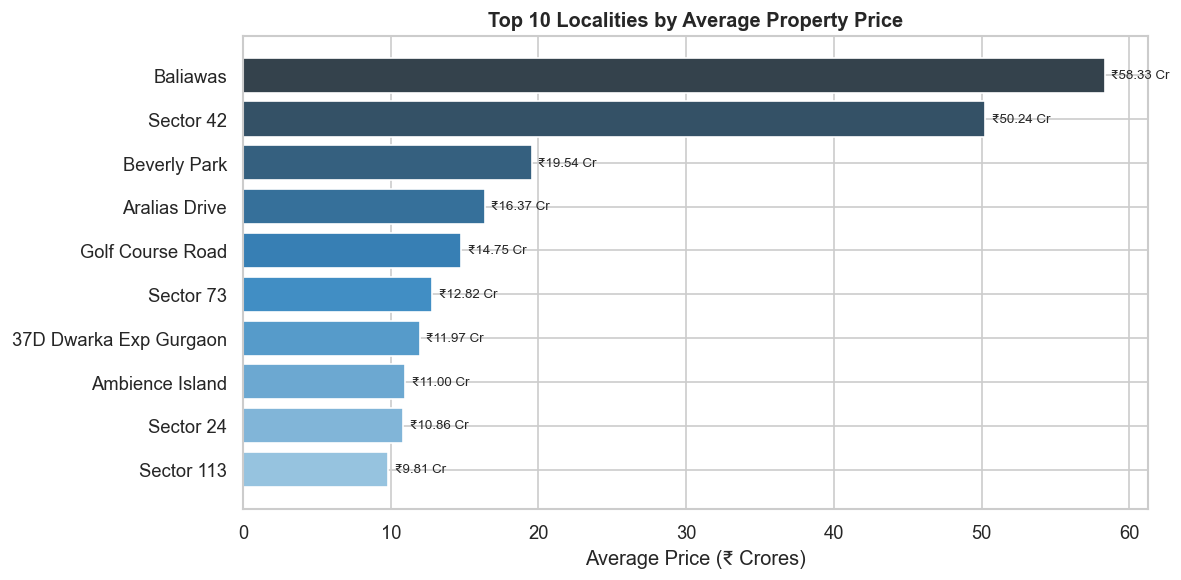


📍 Highest avg price: Baliawas — ₹58.33 Cr


In [8]:
top_localities = (df.groupby('locality')['price']
                    .mean()
                    .sort_values(ascending=False)
                    .head(10) / CRORE)

fig, ax = plt.subplots()
bars = ax.barh(top_localities.index[::-1], top_localities.values[::-1],
               color=sns.color_palette('Blues_d', len(top_localities)))
ax.bar_label(bars, fmt='₹%.2f Cr', padding=4, fontsize=8)
ax.set_xlabel('Average Price (₹ Crores)')
ax.set_title('Top 10 Localities by Average Property Price', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📍 Highest avg price: {top_localities.idxmax()} — ₹{top_localities.max():.2f} Cr")


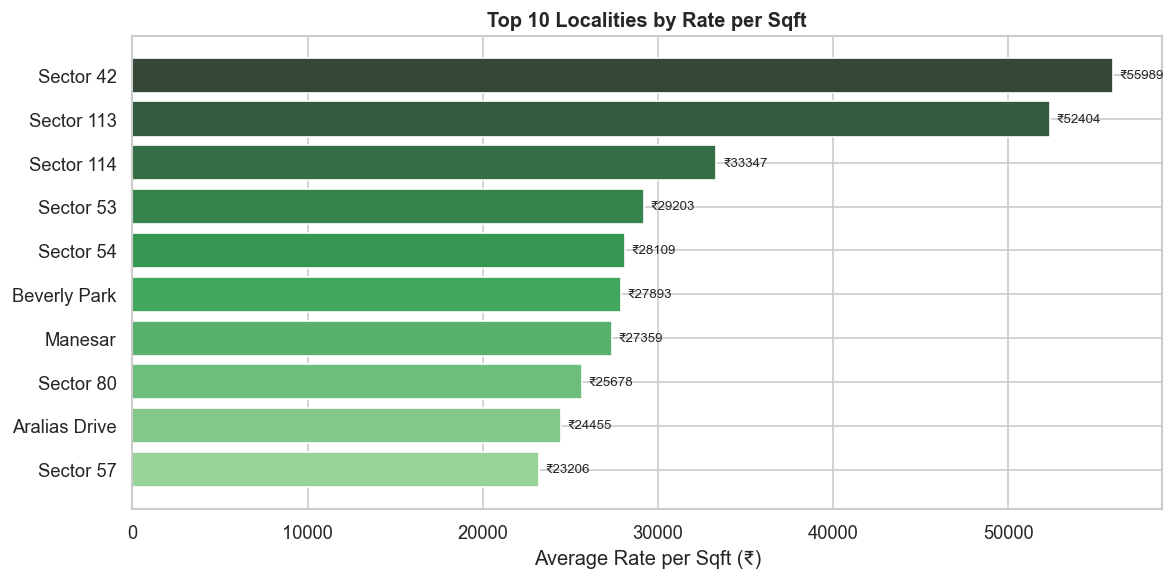


📍 Highest rate/sqft: Sector 42 — ₹55,989/sqft


In [9]:
top_rate = (df.groupby('locality')['rate_per_sqft']
              .mean()
              .sort_values(ascending=False)
              .head(10))

fig, ax = plt.subplots()
bars = ax.barh(top_rate.index[::-1], top_rate.values[::-1],
               color=sns.color_palette('Greens_d', len(top_rate)))
ax.bar_label(bars, fmt='₹%.0f', padding=4, fontsize=8)
ax.set_xlabel('Average Rate per Sqft (₹)')
ax.set_title('Top 10 Localities by Rate per Sqft', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📍 Highest rate/sqft: {top_rate.idxmax()} — ₹{top_rate.max():,.0f}/sqft")

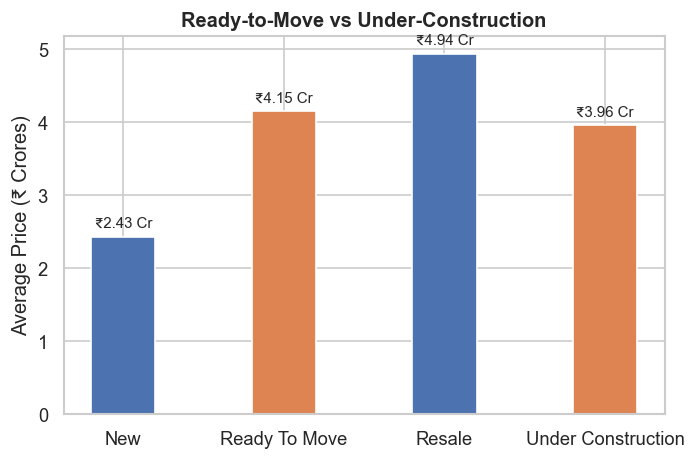


💡 Resale properties are pricier by ₹2.51 Cr on average.


In [10]:
status_price = df.groupby('status')['price'].mean() / CRORE

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(status_price.index.str.title(), status_price.values,
              color=['#4C72B0', '#DD8452'], width=0.4)
ax.bar_label(bars, fmt='₹%.2f Cr', padding=4, fontsize=9)
ax.set_ylabel('Average Price (₹ Crores)')
ax.set_title('Ready-to-Move vs Under-Construction', fontweight='bold')
plt.tight_layout()
plt.show()

winner = status_price.idxmax().title()
diff = abs(status_price.max() - status_price.min())
print(f"\n💡 {winner} properties are pricier by ₹{diff:.2f} Cr on average.")

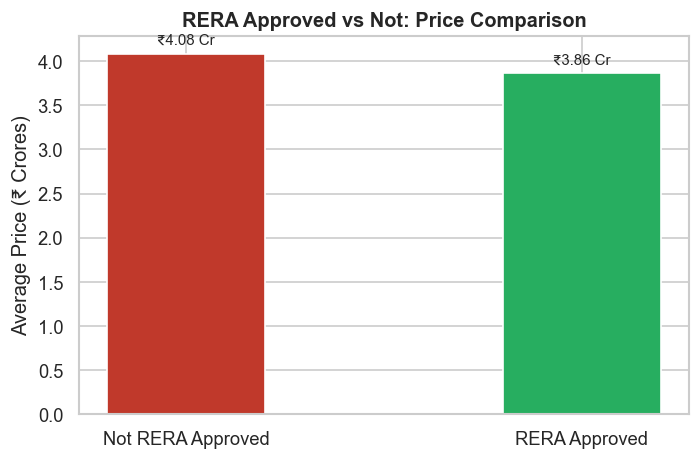


💡 No RERA price premium found.


In [11]:
rera_price = df.groupby('rera_approval')['price'].mean() / CRORE
rera_price.index = ['Not RERA Approved', 'RERA Approved']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(rera_price.index, rera_price.values,
              color=['#c0392b', '#27ae60'], width=0.4)
ax.bar_label(bars, fmt='₹%.2f Cr', padding=4, fontsize=9)
ax.set_ylabel('Average Price (₹ Crores)')
ax.set_title('RERA Approved vs Not: Price Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

premium = rera_price['RERA Approved'] - rera_price['Not RERA Approved']
print(f"\n💡 RERA premium: ₹{premium:.2f} Cr" if premium > 0 else "\n💡 No RERA price premium found.")

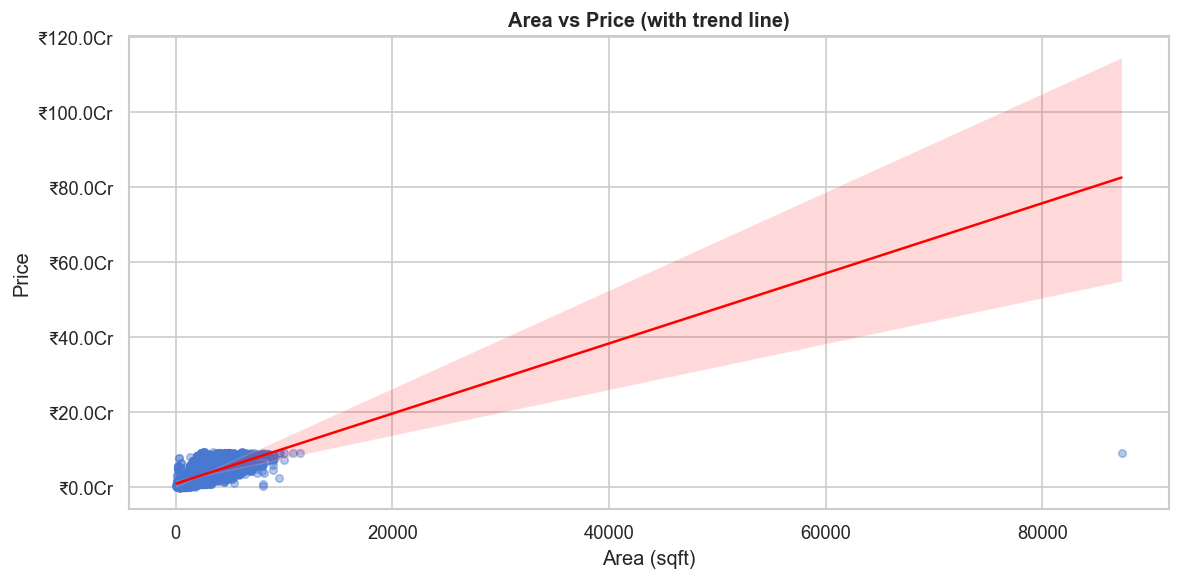


📊 Correlation (Area vs Price): 0.63


In [12]:
Q1, Q3 = df['price'].quantile(0.25), df['price'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[df['price'].between(Q1 - 1.5*IQR, Q3 + 1.5*IQR)]

fig, ax = plt.subplots()
sns.regplot(x='area', y='price', data=df_clean, ax=ax,
            scatter_kws={'alpha': 0.4, 's': 20},
            line_kws={'color': 'red', 'linewidth': 1.5})
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/CRORE:.1f}Cr'))
ax.set_xlabel('Area (sqft)')
ax.set_ylabel('Price')
ax.set_title('Area vs Price (with trend line)', fontweight='bold')
plt.tight_layout()
plt.show()

corr = df_clean[['area', 'price']].corr().iloc[0, 1]
print(f"\n📊 Correlation (Area vs Price): {corr:.2f}")

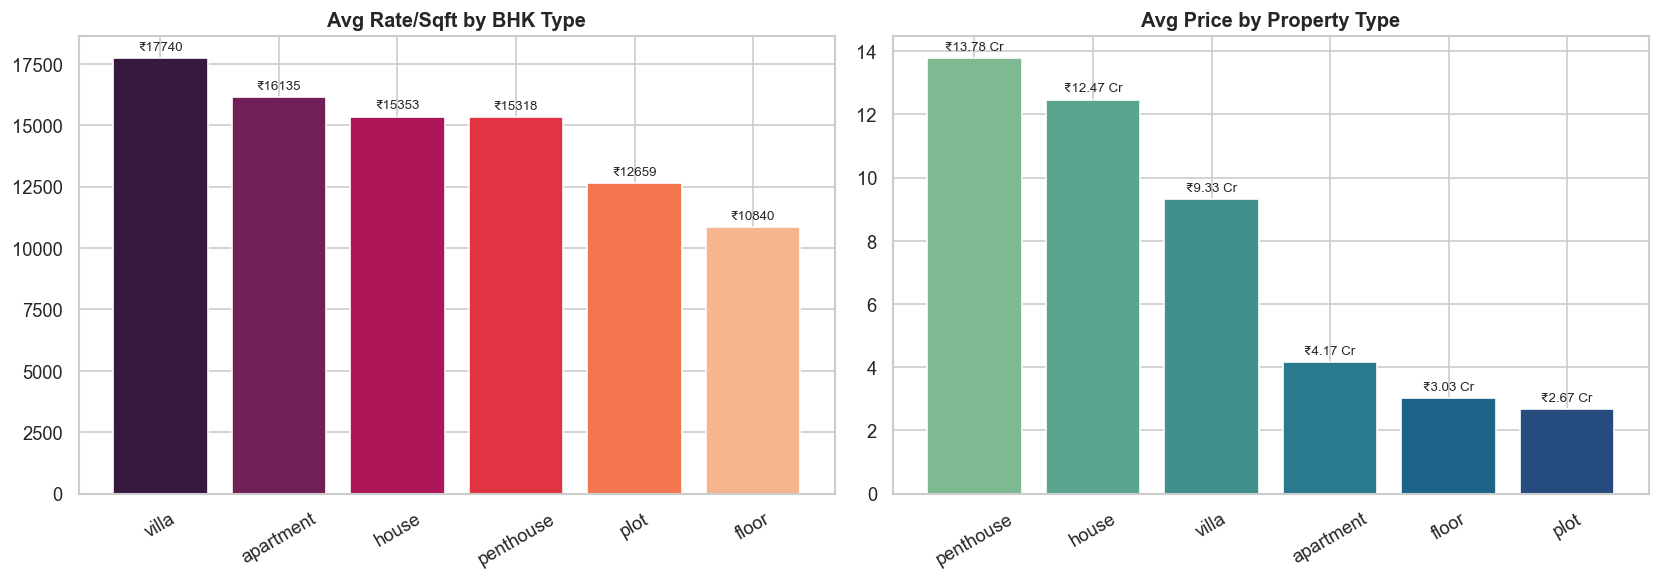

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q7 - Rate per sqft by BHK
bhk_rate = df.groupby('flat_type')['rate_per_sqft'].mean().sort_values(ascending=False)
bars = axes[0].bar(bhk_rate.index, bhk_rate.values,
                   color=sns.color_palette('rocket', len(bhk_rate)))
axes[0].bar_label(bars, fmt='₹%.0f', padding=3, fontsize=8)
axes[0].set_title('Avg Rate/Sqft by BHK Type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Q8 - Avg price by property type
type_price = df.groupby('flat_type')['price'].mean().sort_values(ascending=False) / CRORE
bars2 = axes[1].bar(type_price.index, type_price.values,
                    color=sns.color_palette('crest', len(type_price)))
axes[1].bar_label(bars2, fmt='₹%.2f Cr', padding=3, fontsize=8)
axes[1].set_title('Avg Price by Property Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

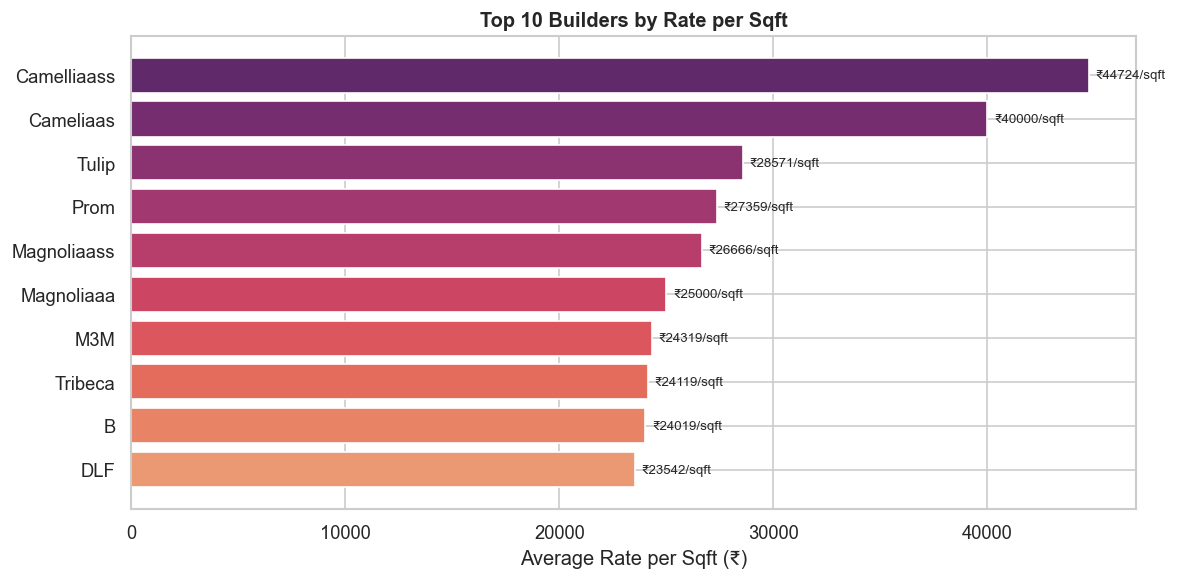


🏗️ Top 5 premium builders:
  1. Camelliaass — ₹44,724/sqft
  2. Cameliaas — ₹40,000/sqft
  3. Tulip — ₹28,571/sqft
  4. Prom — ₹27,359/sqft
  5. Magnoliaass — ₹26,666/sqft


In [14]:
top_builders = (df.groupby('company_name')['rate_per_sqft']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots()
bars = ax.barh(top_builders.index[::-1], top_builders.values[::-1],
               color=sns.color_palette('flare', len(top_builders)))
ax.bar_label(bars, fmt='₹%.0f/sqft', padding=4, fontsize=8)
ax.set_xlabel('Average Rate per Sqft (₹)')
ax.set_title('Top 10 Builders by Rate per Sqft', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏗️ Top 5 premium builders:')
for i, (builder, rate) in enumerate(top_builders.head(5).items(), 1):
    print(f"  {i}. {builder} — ₹{rate:,.0f}/sqft")

ValueError: Could not interpret value `size_category` for `x`. An entry with this name does not appear in `data`.

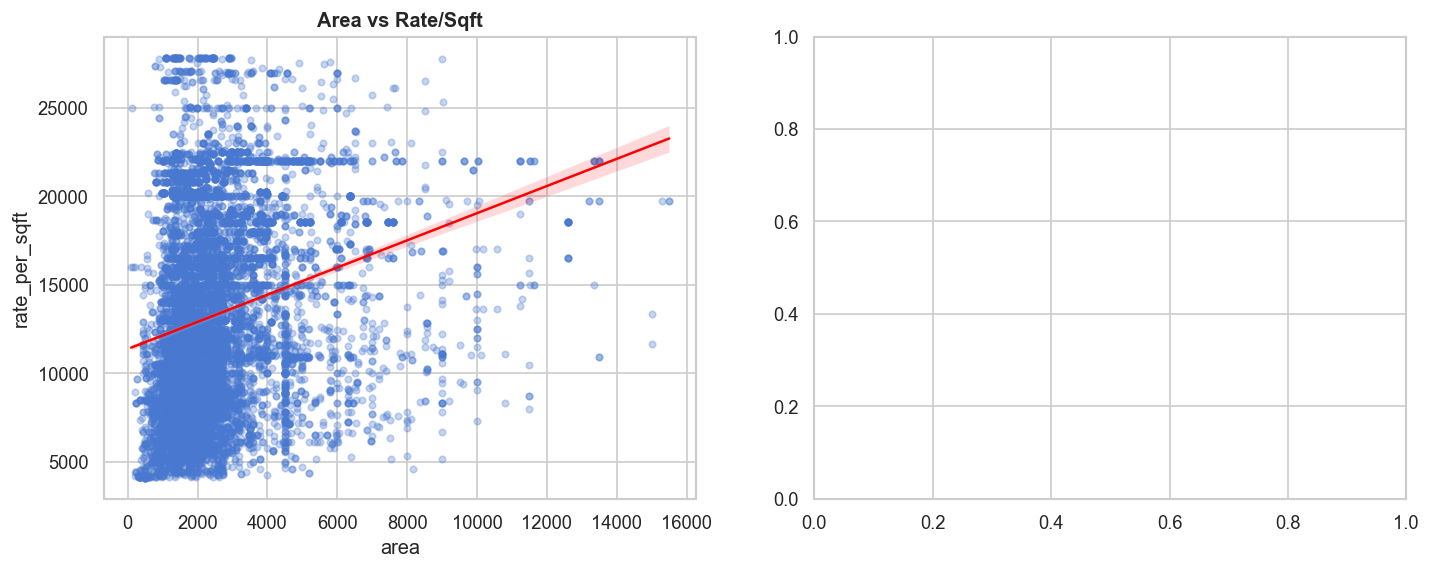

In [15]:
Q1r, Q3r = df['rate_per_sqft'].quantile(0.05), df['rate_per_sqft'].quantile(0.95)
df_r = df[df['rate_per_sqft'].between(Q1r, Q3r)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='area', y='rate_per_sqft', data=df_r, ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 15},
            line_kws={'color': 'red', 'linewidth': 1.5})
axes[0].set_title('Area vs Rate/Sqft', fontweight='bold')

df['size_category'] = pd.cut(df['area'],
                              bins=[0, 1000, 2000, 3000, 5000, df['area'].max()],
                              labels=['<1k', '1k-2k', '2k-3k', '3k-5k', '5k+'])
sns.boxplot(x='size_category', y='rate_per_sqft', data=df_r,
            order=['<1k', '1k-2k', '2k-3k', '3k-5k', '5k+'],
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Rate/Sqft by Size Category', fontweight='bold')

plt.tight_layout()
plt.show()

corr2 = df_r[['area', 'rate_per_sqft']].corr().iloc[0, 1]
print(f"\n📊 Correlation (Area vs Rate/Sqft): {corr2:.2f}")
print("💡 Larger homes don't always cost more per sqft.")

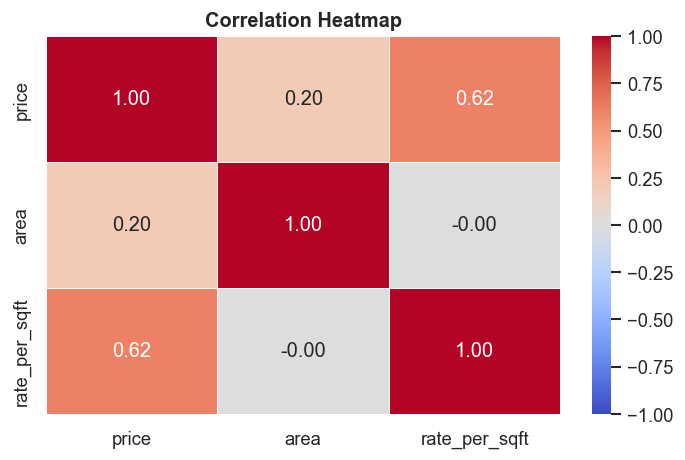

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df[['price', 'area', 'rate_per_sqft']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()